## Import Statements

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve,auc

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")

## Loading Data

In [2]:
try:
    df=pd.read_csv("emails.csv")
    df.drop_duplicates(inplace=True)
    df.dropna(inplace=True)
except:
    print("emails.csv file not found")
    exit()

## Cleaning Text

In [3]:
def clean_text(text):
    text=re.sub(r"^Subject:\s*","",str(text).lower())
    text=re.sub(r"\W", " ", text)
    return " ".join(text.split())

df["text"]=df["text"].apply(clean_text)

## TF-IDF Interpretation

In [4]:
tfidf=TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2)
)

X=tfidf.fit_transform(df["text"])
y=df["spam"].values

## Train Test Splitting

In [5]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Declaring Models

In [6]:
try:
    best_threshold=joblib.load('threshold.pkl')
except:
    best_threshold=0.5

models={
    "Naive Bayes":MultinomialNB(alpha=0.1,fit_prior=True),
    "Logistic Regression":LogisticRegression(
    solver="liblinear",
    class_weight="balanced"
),
    "Random Forest": RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)
}

results=[]
trained_models={}

for name, model in models.items():

    model.fit(X_train,y_train)

    if hasattr(model, "predict_proba"):
        y_probs=model.predict_proba(X_test)[:,1]
        y_pred=(y_probs >= best_threshold).astype(int)
    else:
        y_pred=model.predict(X_test)

    acc=accuracy_score(y_test, y_pred)
    prec=precision_score(y_test, y_pred)
    rec=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)

    results.append({
        "Model":name,
        "Accuracy":acc,
        "Precision":prec,
        "Recall":rec,
        "F1-Score":f1
    })

    trained_models[name] = {
    "model":model,
    "probs":y_probs
    } 


## Performance Comparison (All Metrics)

In [7]:
perf_df=pd.DataFrame(results).set_index("Model")

print("="*50)
print("MODEL COMPARISON TABLE")
print("="*50)
print(perf_df.round(4))

MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Naive Bayes            0.9903     0.9817  0.9781    0.9799
Logistic Regression    0.9912     0.9714  0.9927    0.9819
Random Forest          0.9868     0.9675  0.9781    0.9728


## Winner Model Based On Comparison

In [8]:
best_model_name=perf_df["Recall"].idxmax()
best_model=trained_models[best_model_name]["model"]
best_probs = trained_models[best_model_name]["probs"]

print(f"\nWINNER MODEL(Based on recall):{best_model_name}")


WINNER MODEL(Based on recall):Logistic Regression


## Precision-Recall Curve

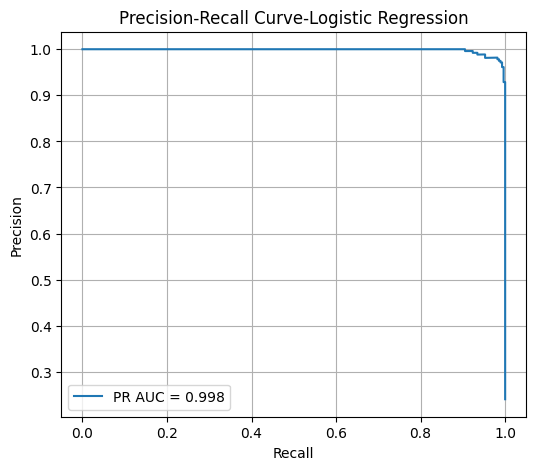

In [9]:
if best_probs is not None:

    precision, recall, thresholds = precision_recall_curve(y_test, best_probs)
    pr_auc=auc(recall, precision)

    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.3f}")
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve-{best_model_name}")
    
    plt.legend()
    plt.grid()
    plt.show()

else:
    print("Precision-Recall curve not supported for this model")

## Performance Comparison Visualization

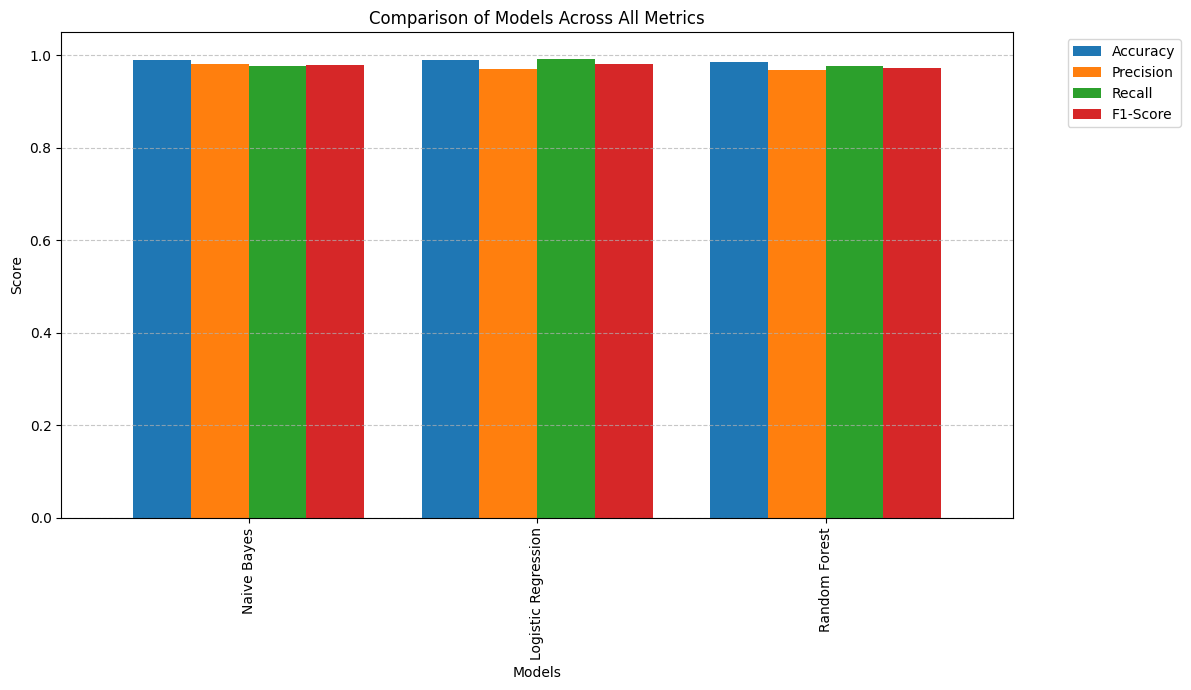

In [10]:
ax = perf_df.plot(kind="bar",figsize=(12,7),width=0.8)

plt.title("Comparison of Models Across All Metrics")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.grid(axis="y",linestyle="--",alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1),loc='upper left')
plt.tight_layout()
plt.show()

## Confusion Matrix

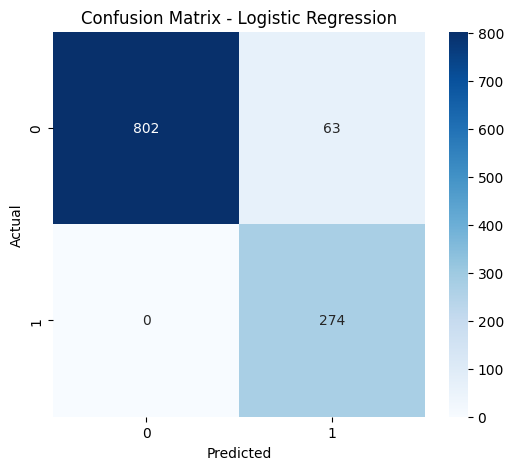

In [11]:
if best_probs is not None:
    y_pred_best = (best_probs > 0.3).astype(int)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## ROC Curve

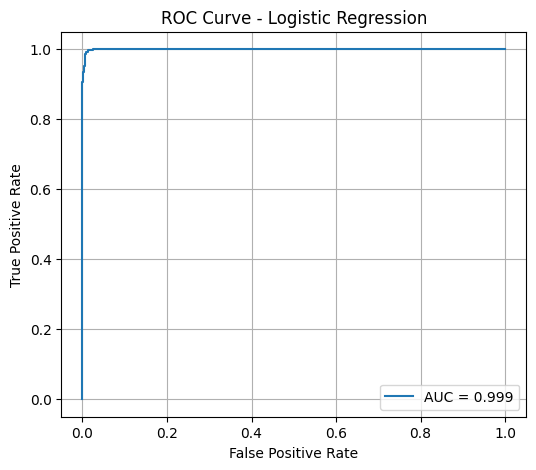

In [12]:
if best_probs is not None:
    y_probs=best_probs
else:
    y_probs=best_model.predict_proba(X_test)[:,1]

fpr, tpr, _=roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.grid()
plt.show()

## Top Words in Ham and Spam Graph

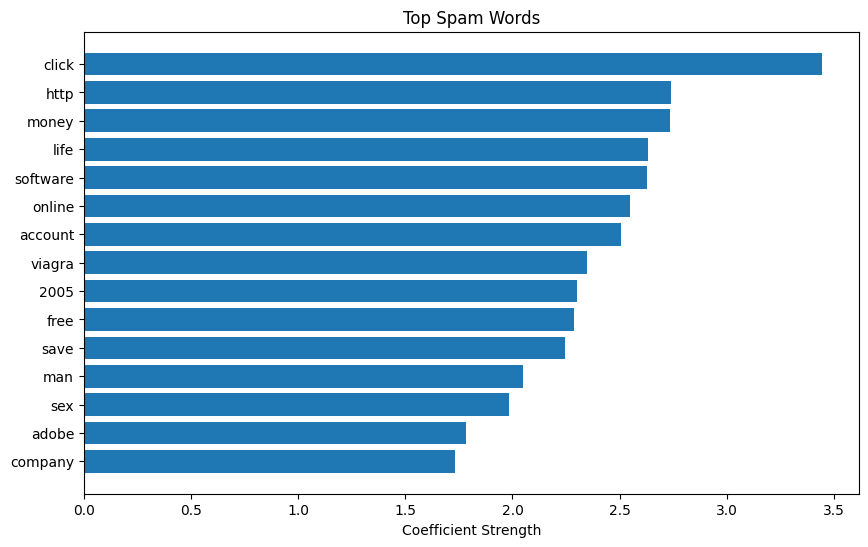

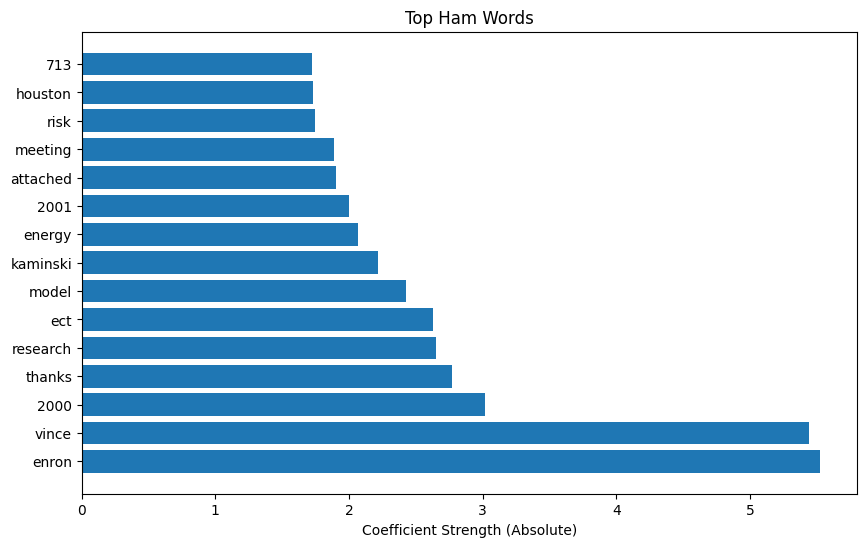

In [13]:
if best_model_name=="Logistic Regression":

    feature_names=np.array(tfidf.get_feature_names_out())
    coefs=best_model.coef_[0]
    sorted_idx=np.argsort(coefs)

    ham_idx=sorted_idx[:15]
    spam_idx=sorted_idx[-15:]

    spam_words=feature_names[spam_idx]
    ham_words=feature_names[ham_idx]
    
    spam_importances=coefs[spam_idx]
    ham_importances=abs(coefs[ham_idx])

    plt.figure(figsize=(10, 6))
    plt.barh(spam_words, spam_importances)
    plt.title("Top Spam Words")
    plt.xlabel("Coefficient Strength")
    plt.show()

    plt.figure(figsize=(10,6))
    plt.barh(ham_words, ham_importances)
    plt.title("Top Ham Words")
    plt.xlabel("Coefficient Strength (Absolute)")
    plt.show()


## Prediction of Emails -> Ham or Spam

In [ ]:
import joblib, re

_model=joblib.load('spam_model.pkl')
_tfidf=joblib.load('tfidf_vectorizer.pkl')
_threshold=joblib.load('threshold.pkl')

def _clean(text):
    text=re.sub(r'^Subject:\s*','',str(text).lower())
    text=re.sub(r'\W',' ',text)
    return' '.join(text.split())

print('\n'+'='*50)
print(f'Threshold={_threshold:.4f}')
print('='*50)

while True:
    msg=input('\nEnter Email Text(or type exit):')
    if msg.lower()=='exit':
        print('Exiting System')
        break
    cleaned=_clean(msg)
    vec=_tfidf.transform([cleaned])
    prob_spam=_model.predict_proba(vec)[0][1]
    if prob_spam>=_threshold:
        print(f'SPAM({prob_spam:.2%})')
    else:
        print(f'HAM({1 - prob_spam:.2%})')


Threshold=0.5344



Enter Email Text(or type exit): madhav


HAM(56.80%)



Enter Email Text(or type exit): buy 1 get 1


SPAM(64.62%)
